# ---------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ---------------------------------------------------------

In [1]:
import pandas as pd             # For data manipulation and analysis
import matplotlib.pyplot as plt # For standard plotting capabilities
import seaborn as sns           # For making the plots look visually appealing

# Set a beautiful default theme for all our charts

In [2]:
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------

In [4]:
df = pd.read_csv('Sales.csv')

In [5]:
df

,ProductID,Date,CustomerID,CampaignID,Units,Product,Category,Segment,ManufacturerID,Manufacturer,Unit Cost,Unit Price,ZipCode,Email Name,City,State,Region,District,Country
0,449,2012-07-26 00:00:00.000,247546,22,1,Maximus UM-54,Urban,Moderation,7,VanArsdel,74.729917,102.36975,33194,"(Nerea.Barry@xyza.com): Barry, Nerea","Miami, FL, USA",FL,East,District #10,USA
1,449,2013-10-31 00:00:00.000,124593,22,1,Maximus UM-54,Urban,Moderation,7,VanArsdel,74.729917,102.36975,33177,"(Elliott.Stuart@xyza.com): Stuart, Elliott","Miami, FL, USA",FL,East,District #10,USA
2,449,2013-11-14 00:00:00.000,163517,22,1,Maximus UM-54,Urban,Moderation,7,VanArsdel,74.729917,102.36975,33172,"(Holmes.Swanson@xyza.com): Swanson, Holmes","Miami, FL, USA",FL,East,District #10,USA
3,449,2013-01-17 00:00:00.000,8875,18,1,Maximus UM-54,Urban,Moderation,7,VanArsdel,74.729917,102.36975,33169,"(Nyssa.Solis@xyza.com): Solis, Nyssa","Miami, FL, USA",FL,East,District #10,USA
4,449,2014-09-13 00:00:00.000,8894,21,1,Maximus UM-54,Urban,Moderation,7,VanArsdel,74.729917,102.36975,33169,"(Ivana.Wall@xyza.com): Wall, Ivana","Miami, FL, USA",FL,East,District #10,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,407,2012-05-20 00:00:00.000,32464,3,1,Maximus UM-12,Accessory,Accessory,7,VanArsdel,116.887417,160.11975,32404,"(Catherine.Martinez@xyza.com): Martinez, Cathe...","Panama City, FL, USA",FL,East,District #09,USA
675364,407,2011-03-02 00:00:00.000,32441,5,1,Maximus UM-12,Accessory,Accessory,7,VanArsdel,116.887417,160.11975,32404,"(Dora.Emerson@xyza.com): Emerson, Dora","Panama City, FL, USA",FL,East,District #09,USA
675365,407,2012-06-02 00:00:00.000,101533,1,1,Maximus UM-12,Accessory,Accessory,7,VanArsdel,116.887417,160.11975,32514,"(Lynn.Jones@xyza.com): Jones, Lynn","Pensacola, FL, USA",FL,East,District #09,USA
675366,407,2011-04-10 00:00:00.000,147192,4,1,Maximus UM-12,Accessory,Accessory,7,VanArsdel,116.887417,160.11975,32407,"(Maite.Cantrell@xyza.com): Cantrell, Maite","Panama City Beach, FL, USA",FL,East,District #09,USA


# ---------------------------------------------------------
# 3. DATA CLEANING & FEATURE ENGINEERING
# ---------------------------------------------------------

In [6]:
# Convert the 'Date' column from a string (text) to true DateTime object
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Drop any rows that have completely missing values to avoid errors in math
df.dropna(inplace=True)

In [8]:
# Drop duplicate rows if the exact same transaction was recorded twice
df.drop_duplicates(inplace=True)

# Feature Engineering

In [11]:
# Total Revenue = (Number of Units) x (Selling Price)
df['Revenue'] = df['Units'] * df['Unit Price']
df['Revenue']

0         102.36975
1         102.36975
2         102.36975
3         102.36975
4         102.36975
            ...    
675363    160.11975
675364    160.11975
675365    160.11975
675366    160.11975
675367    160.11975
Name: Revenue, Length: 675235, dtype: float64

In [12]:
# Total Cost = (Number of Units) x (Cost to make it)
df['Total Cost'] = df['Units'] * df['Unit Cost']
df['Total Cost'] 

0          74.729917
1          74.729917
2          74.729917
3          74.729917
4          74.729917
             ...    
675363    116.887417
675364    116.887417
675365    116.887417
675366    116.887417
675367    116.887417
Name: Total Cost, Length: 675235, dtype: float64

In [13]:
# Profit = Total Revenue minus Total Cost
df['Profit'] = df['Revenue'] - df['Total Cost']
df['Profit']

0         27.639832
1         27.639832
2         27.639832
3         27.639832
4         27.639832
            ...    
675363    43.232333
675364    43.232333
675365    43.232333
675366    43.232333
675367    43.232333
Name: Profit, Length: 675235, dtype: float64

# ---------------------------------------------------------
# 4. EXPLORATORY DATA ANALYSIS (EDA) & 5 VISUALIZATIONS
# ---------------------------------------------------------

C:\Users\ayush\AppData\Local\Temp\ipykernel_20392\2389895737.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='Date')['Revenue'].sum()


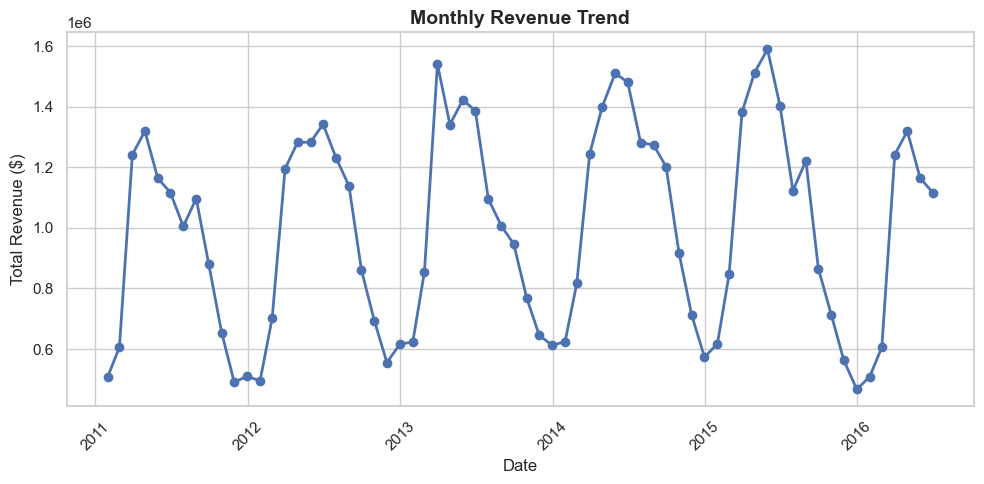

In [27]:
plt.figure(figsize=(10, 5))
# Group the data by month ('M') and sum up the revenue for that month
monthly_revenue = df.resample('M', on='Date')['Revenue'].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='b', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45) # Rotate dates so they don't overlap
plt.tight_layout()
plt.savefig('viz1_revenue_trend.png') # Save the plot as an image
plt.show()

C:\Users\ayush\AppData\Local\Temp\ipykernel_20392\2063718113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis')


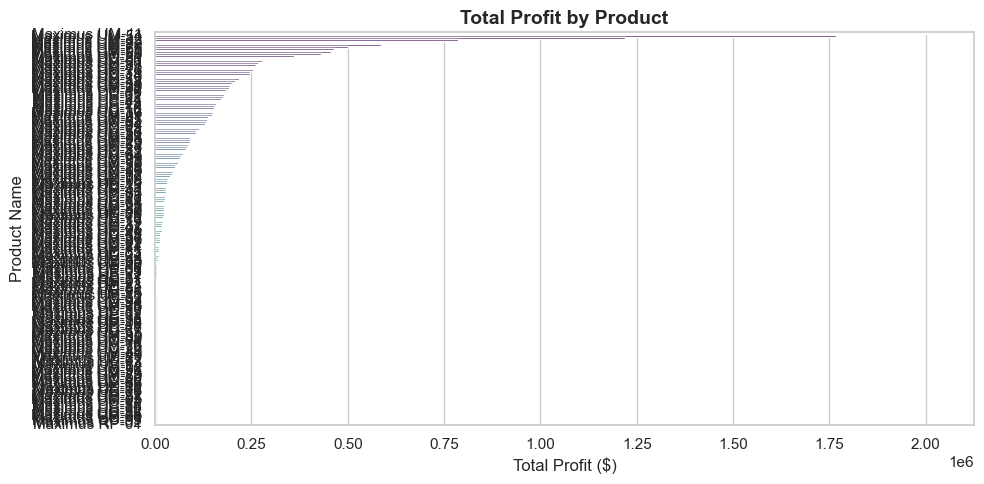

In [26]:
# --- Visualization 2: Top Products by Total Profit ---
plt.figure(figsize=(10, 5))
# Group by product, sum the profit, and sort from highest to lowest
product_profit = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis')
plt.title('Total Profit by Product', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('viz2_product_profit.png')
plt.show()

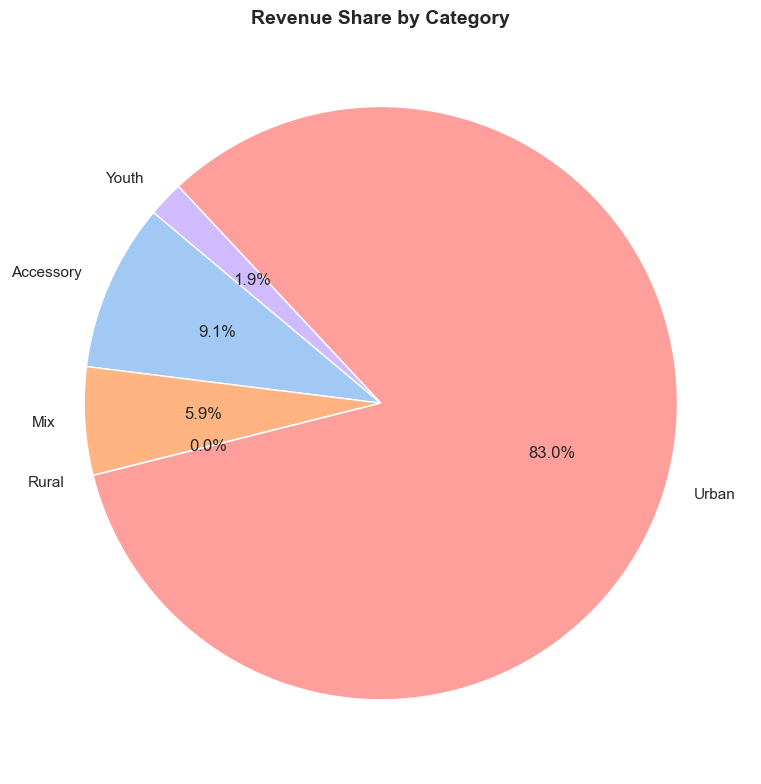

In [25]:
# --- Visualization 3: Revenue Share by Category ---
plt.figure(figsize=(8, 8))
# Sum up the revenue for each distinct category
category_sales = df.groupby('Category')['Revenue'].sum()
# Create a pie chart to visualize the percentage split
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Share by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_category_share.png')
plt.show()

C:\Users\ayush\AppData\Local\Temp\ipykernel_20392\2313386868.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=manufacturer_profit.index, y=manufacturer_profit.values, palette='magma')


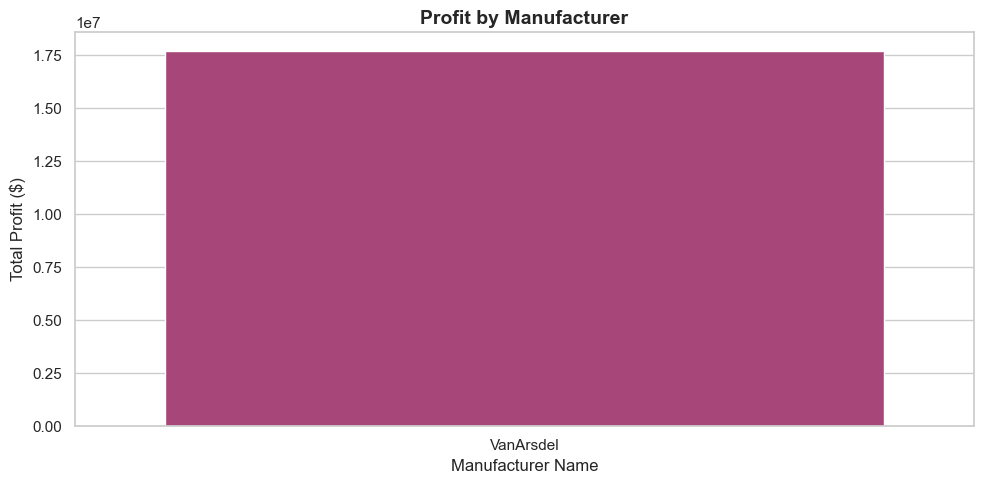

In [24]:
# --- Visualization 4: Profit by Manufacturer ---
plt.figure(figsize=(10, 5))
# Group by manufacturer, sum the profit, and sort
manufacturer_profit = df.groupby('Manufacturer')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=manufacturer_profit.index, y=manufacturer_profit.values, palette='magma')
plt.title('Profit by Manufacturer', fontsize=14, fontweight='bold')
plt.xlabel('Manufacturer Name')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('viz4_manufacturer_profit.png')
plt.show()

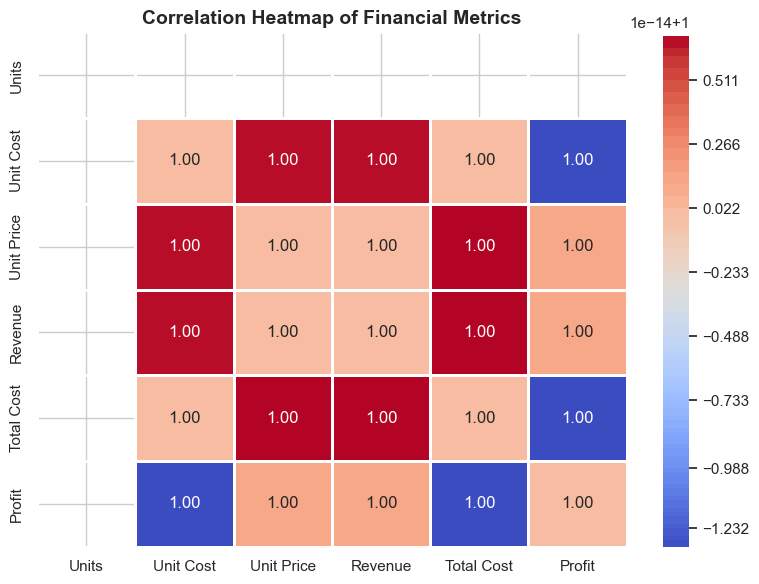

In [23]:
# --- Visualization 5: Correlation Heatmap of Financials ---
plt.figure(figsize=(8, 6))
# Select only the columns that have numerical financial data
numeric_cols = df[['Units', 'Unit Cost', 'Unit Price', 'Revenue', 'Total Cost', 'Profit']]
# Calculate the correlation matrix and plot it
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Heatmap of Financial Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_correlation.png')
plt.show()